# FNO Conditioning Encoder Ablation — Results

Compares five encoder architectures (RRDB CNN baseline vs FNO-A/B/C/pnemo) on the temperature field, at two levels:

1. **Encoder only** — direct SR output of each frozen encoder (no diffusion).
2. **Diffusion + encoder** — DDIM-sampled DDPM conditioned on each frozen encoder.

Predictions are pre-computed by SLURM jobs and loaded from W&B artifacts — no GPU needed locally.

**Before running:** fill in `wandb_run_name` in the VARIANTS cell below.  
Run `cat diffusionsr/runs/fno_ablation/enc_<arm>/wandb_run_name.txt` on TRACE to get each name.

In [1]:
RUNS_DIR  = '/trace/group/forgelab/ngng/multifield/DiffusionSR_shohom/diffusionsr/runs/fno_ablation'
DATA_ROOT = '/trace/group/forgelab/ngng/multifield/data_fields'
EVAL_OUT_DIR = '/trace/group/forgelab/ngng/multifield/DiffusionSR_shohom/diffusionsr/eval_outputs/fno_ablation'

N_STEPS    = 1
BATCH_SIZE = 4
DEVICE     = 'cuda'
TIMESTEPS  = 1000
SCHEDULE   = 'linear'


In [2]:
%matplotlib inline
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display as _ipy_display

_plt_show_orig = plt.show
def _show(*a, **kw):
    for n in plt.get_fignums(): _ipy_display(plt.figure(n))
    plt.close('all')
plt.show = _show

def find_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p/'setup.py').exists() and (p/'diffusionsr').exists(): return p
    raise RuntimeError('Could not find project root')
PROJECT_ROOT = find_root()
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
print(f'PROJECT_ROOT: {PROJECT_ROOT}')


PROJECT_ROOT: c:\Users\nevin\Desktop\forge_research_project\DiffusionSR_shohom


In [3]:
from diffusionsr.analysis.analysis_functions import get_profile

def mae_rmse(p, g):
    p, g = np.asarray(p).ravel(), np.asarray(g).ravel()
    return {'MAE': float(np.mean(np.abs(p-g))), 'RMSE': float(np.sqrt(np.mean((p-g)**2)))}

def load_wandb_preds(v):
    import wandb
    api = wandb.Api()
    entity = os.getenv('WANDB_ENTITY', 'ngng-')
    artifact = api.artifact(f"{entity}/Flow3D_SuperResolution/{v['run_name']}_eval_predictions:latest")
    d = np.load(os.path.join(artifact.download(), 'predictions.npz'), allow_pickle=True)
    return d['pred'], d['gt']

def plot_comparison(panels, title, ch=0):
    fig, axes = plt.subplots(1, len(panels), figsize=(4.5*len(panels), 4), dpi=120)
    if len(panels) == 1: axes = [axes]
    for ax, (ttl, data) in zip(axes, panels):
        ax.imshow(data.T, origin='lower', cmap='jet', vmin=293, vmax=5000, aspect='auto')
        ax.set_title(ttl, fontsize=9); ax.axis('off')
    plt.suptitle(title, fontsize=10); plt.tight_layout(); plt.show()

def plot_loss_curves(v, model_label, project='Flow3D_SuperResolution'):
    import wandb
    api = wandb.Api()
    entity = os.environ.get('WANDB_ENTITY', 'ngng-')
    proj = v.get('wandb_project', project)
    if v.get('wandb_run_id'):
        # Fetch by unique run_id (handles cases where display_name is not unique)
        try:
            run = api.run(f"{entity}/{proj}/{v['wandb_run_id']}")
            runs = [run]
        except Exception as _e:
            print(f"Could not fetch run id {v['wandb_run_id']}: {_e}"); return
    elif v.get('wandb_run_name'):
        runs = list(api.runs(f"{entity}/{proj}", filters={"display_name": v['wandb_run_name']}))
        if not runs: print(f"No W&B run found: {v['wandb_run_name']}"); return
    else:
        print(f"No wandb_run_id or wandb_run_name set for {v['run_name']}"); return
    fig, ax = plt.subplots(figsize=(9, 4), dpi=120)
    for col, ls in [("train_loss","-"),("test_loss","--"),("val_loss",":")]:
        h = runs[0].history(keys=[col], samples=10000, pandas=True)
        if col in h.columns:
            ax.plot(h[col].dropna().values, ls=ls, label=col, lw=1.5, alpha=0.9)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(f"{v['run_name']} ({model_label}) — Training Curves")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

def summarise_metrics(v, preds, gts):
    maes, rmses, mp_errs = [], [], []
    for p, g in zip(preds, gts):
        m = mae_rmse(p[0], g[0]); maes.append(m['MAE']); rmses.append(m['RMSE'])
        try:
            pp, _ = get_profile(p[:1]); gp, _ = get_profile(g[:1])
            mp_errs.append(float(np.mean(np.abs(pp - gp))))
        except Exception: pass
    return {
        'run_name': v['run_name'],
        'MAE_mean': float(np.mean(maes)), 'MAE_std': float(np.std(maes)),
        'RMSE_mean': float(np.mean(rmses)),
        'MP_MAE_mean': float(np.nanmean(mp_errs)) if mp_errs else float('nan'),
    }


c:\Users\nevin\anaconda3\envs\diffusion_SR_local\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[fno_encoder_model] physicsnemo unavailable (ModuleNotFoundError: No module named 'physicsnemo'); using builtin backend


In [4]:
# Encoder runs logged to RRDN_Encoder project (not Flow3D_SuperResolution).
# All four share display_name '23_Sep_2026_encoder' — wandb_run_id is used
# instead of wandb_run_name for unique lookup.
# Diffusion display names come from Phase 2 (02_diffusion_array.sh) wandb_run_name.txt.

ENC_VARIANTS = {
    'rrdb':          {'run_name': 'fno_abl_enc_rrdb',          'wandb_run_id': '2rqjf7vz', 'wandb_project': 'RRDN_Encoder', 'wandb_run_name': '23_Sep_2026_encoder', 'label': 'RRDB CNN (baseline)'},
    'fno_pre':       {'run_name': 'fno_abl_enc_fno_pre',       'wandb_run_id': '5y1fo3jd', 'wandb_project': 'RRDN_Encoder', 'wandb_run_name': '23_Sep_2026_encoder', 'label': 'FNO-A (op@HR)'},
    'fno_spectral':  {'run_name': 'fno_abl_enc_fno_spectral',  'wandb_run_id': '1we1lhh3', 'wandb_project': 'RRDN_Encoder', 'wandb_run_name': '23_Sep_2026_encoder', 'label': 'FNO-B (spectral upsample)'},
    'fno_conv':      {'run_name': 'fno_abl_enc_fno_conv',      'wandb_run_id': 'i4xrhglt', 'wandb_project': 'RRDN_Encoder', 'wandb_run_name': '23_Sep_2026_encoder', 'label': 'FNO-C (conv upsample)'},
    'fno_pre_pnemo': {'run_name': 'fno_abl_enc_fno_pre_pnemo', 'wandb_run_id': '',          'wandb_project': 'RRDN_Encoder', 'wandb_run_name': '',                    'label': 'FNO-A PhysicsNeMo (calibration)'},
}

DIFF_VARIANTS = {
    'rrdb':          {'run_name': 'fno_abl_diff_rrdb',          'wandb_run_name': '24_Sep_2026_fno_abl_diff_rrdb',          'label': 'RRDB CNN (baseline)'},
    'fno_pre':       {'run_name': 'fno_abl_diff_fno_pre',       'wandb_run_name': '24_Sep_2026_fno_abl_diff_fno_pre',       'label': 'FNO-A (op@HR)'},
    'fno_spectral':  {'run_name': 'fno_abl_diff_fno_spectral',  'wandb_run_name': '24_Sep_2026_fno_abl_diff_fno_spectral',  'label': 'FNO-B (spectral upsample)'},
    'fno_conv':      {'run_name': 'fno_abl_diff_fno_conv',      'wandb_run_name': '24_Sep_2026_fno_abl_diff_fno_conv',      'label': 'FNO-C (conv upsample)'},
    'fno_pre_pnemo': {'run_name': 'fno_abl_diff_fno_pre_pnemo', 'wandb_run_name': '',                                       'label': 'FNO-A PhysicsNeMo (calibration)'},
}

ARMS = ['rrdb', 'fno_pre', 'fno_spectral', 'fno_conv', 'fno_pre_pnemo']


## 1. Encoder-Only Results

Direct super-resolution from each frozen encoder (L1-trained, no diffusion).
Artifacts uploaded by `slurm/fno_ablation/04_encoder_eval_array.sh`.

#### RRDB CNN (baseline)


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\nevin\_netrc.


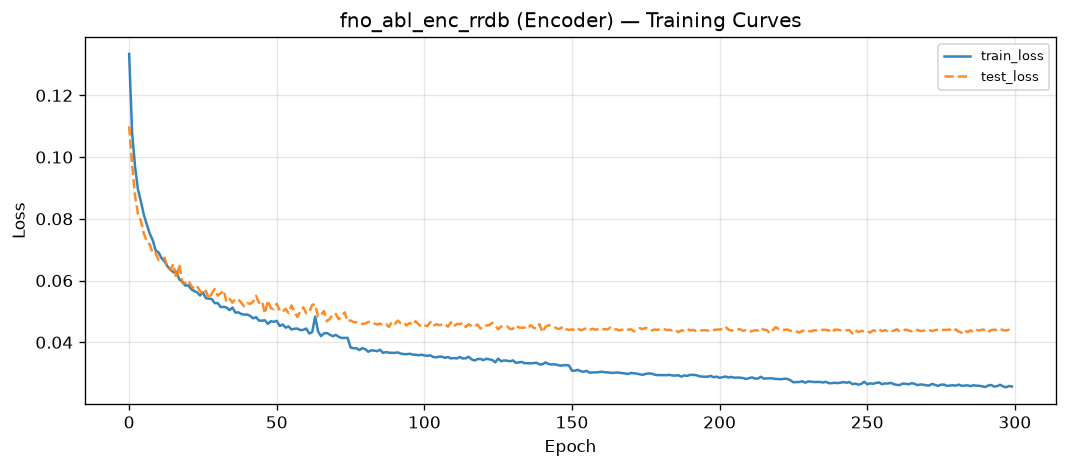

In [5]:
V = ENC_VARIANTS['rrdb']
plot_loss_curves(V, model_label='Encoder')


In [6]:
try:
    preds_enc_rrdb, gts_enc_rrdb = load_wandb_preds(V)
    print(f"Loaded {len(preds_enc_rrdb)} predictions from W&B artifact.")
    _loaded = True
except Exception as _e:
    print(f"Artifact not yet available: {_e}")
    preds_enc_rrdb = gts_enc_rrdb = None; _loaded = False


wandb: Downloading large artifact 'fno_abl_enc_rrdb_eval_predictions:latest', 105.17MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:03.5 (30.3MB/s)


Loaded 3829 predictions from W&B artifact.


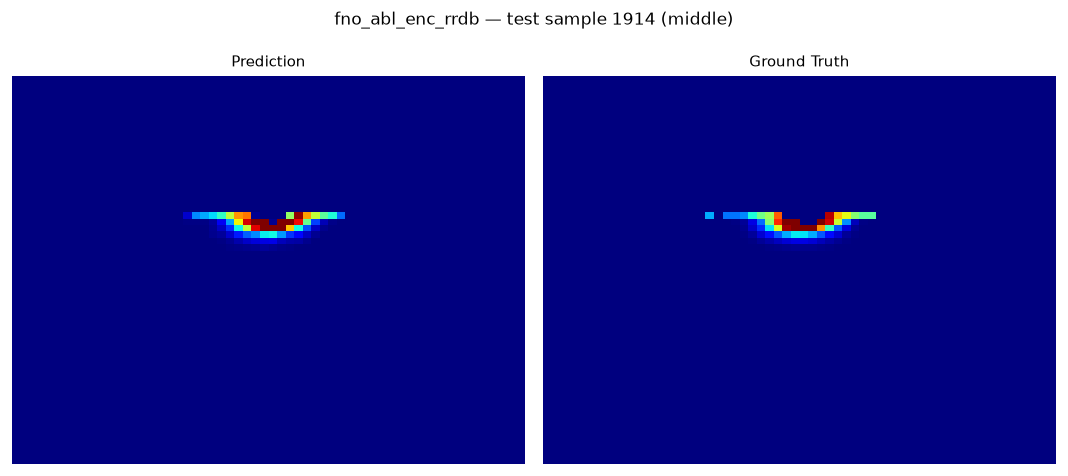

In [7]:
if preds_enc_rrdb is not None:
    _mid = len(preds_enc_rrdb) // 2
    _p = preds_enc_rrdb[_mid]; _g = gts_enc_rrdb[_mid]
    plot_comparison([('Prediction', _p[0]), ('Ground Truth', _g[0])],
                    f"{V['run_name']} — test sample {_mid} (middle)")


#### FNO-A (bicubic→HR, op@HR)


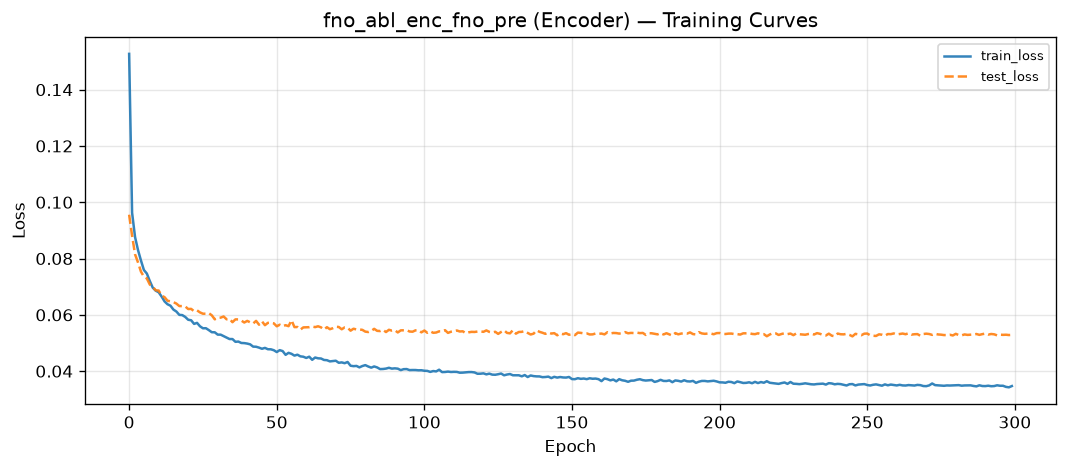

In [8]:
V = ENC_VARIANTS['fno_pre']
plot_loss_curves(V, model_label='Encoder')


In [9]:
try:
    preds_enc_fno_pre, gts_enc_fno_pre = load_wandb_preds(V)
    print(f"Loaded {len(preds_enc_fno_pre)} predictions from W&B artifact.")
    _loaded = True
except Exception as _e:
    print(f"Artifact not yet available: {_e}")
    preds_enc_fno_pre = gts_enc_fno_pre = None; _loaded = False


wandb: Downloading large artifact 'fno_abl_enc_fno_pre_eval_predictions:latest', 105.17MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.2 (420.7MB/s)


Loaded 3829 predictions from W&B artifact.


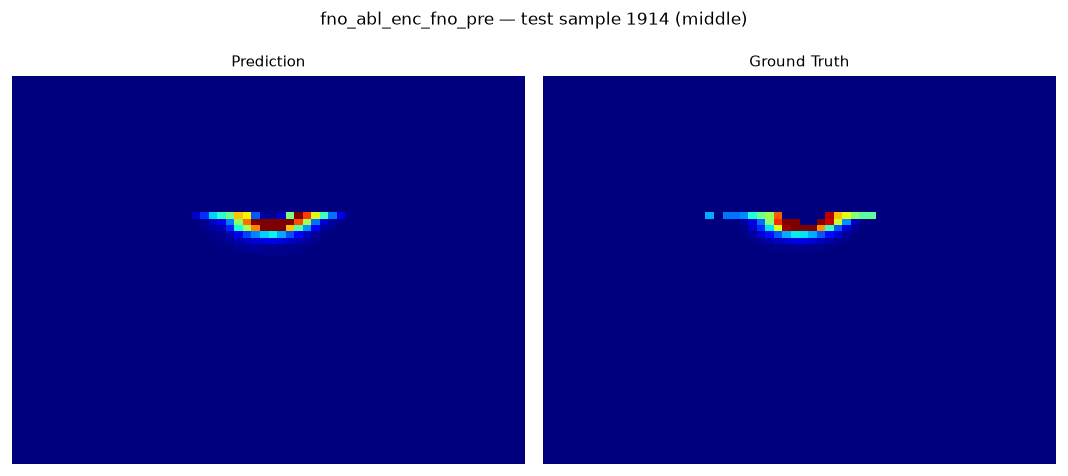

In [10]:
if preds_enc_fno_pre is not None:
    _mid = len(preds_enc_fno_pre) // 2
    _p = preds_enc_fno_pre[_mid]; _g = gts_enc_fno_pre[_mid]
    plot_comparison([('Prediction', _p[0]), ('Ground Truth', _g[0])],
                    f"{V['run_name']} — test sample {_mid} (middle)")


#### FNO-B (op@LR, spectral upsample)


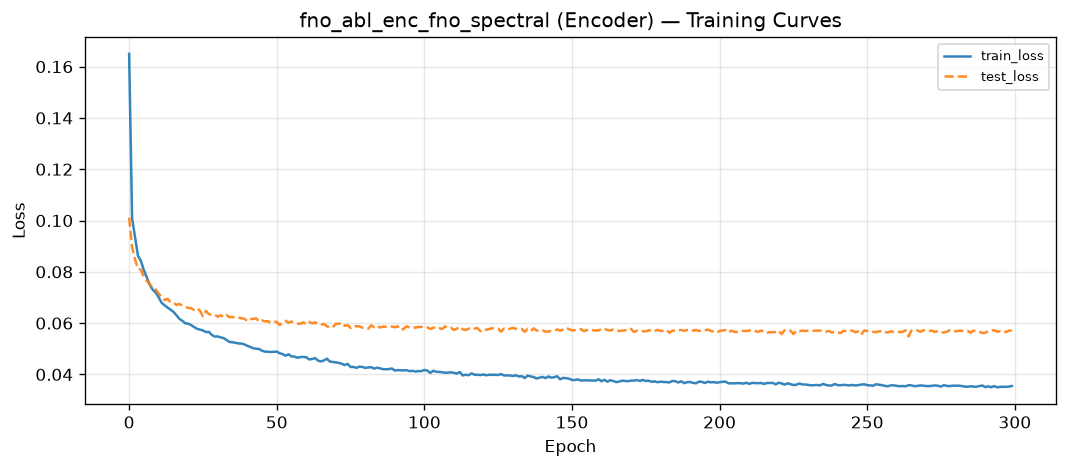

In [11]:
V = ENC_VARIANTS['fno_spectral']
plot_loss_curves(V, model_label='Encoder')


In [12]:
try:
    preds_enc_fno_spectral, gts_enc_fno_spectral = load_wandb_preds(V)
    print(f"Loaded {len(preds_enc_fno_spectral)} predictions from W&B artifact.")
    _loaded = True
except Exception as _e:
    print(f"Artifact not yet available: {_e}")
    preds_enc_fno_spectral = gts_enc_fno_spectral = None; _loaded = False


wandb: Downloading large artifact 'fno_abl_enc_fno_spectral_eval_predictions:latest', 105.17MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.4 (249.8MB/s)


Loaded 3829 predictions from W&B artifact.


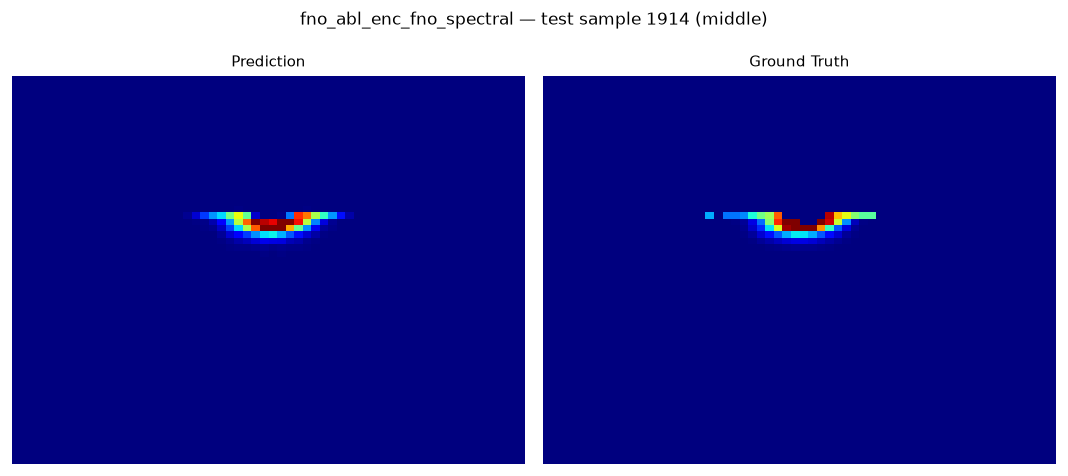

In [13]:
if preds_enc_fno_spectral is not None:
    _mid = len(preds_enc_fno_spectral) // 2
    _p = preds_enc_fno_spectral[_mid]; _g = gts_enc_fno_spectral[_mid]
    plot_comparison([('Prediction', _p[0]), ('Ground Truth', _g[0])],
                    f"{V['run_name']} — test sample {_mid} (middle)")


#### FNO-C (op@LR, conv upsample)


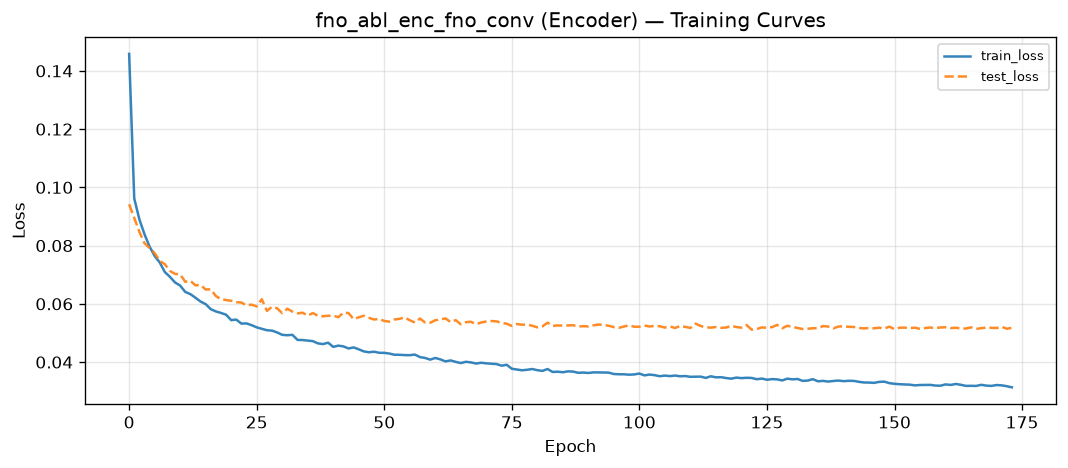

In [14]:
V = ENC_VARIANTS['fno_conv']
plot_loss_curves(V, model_label='Encoder')


In [15]:
try:
    preds_enc_fno_conv, gts_enc_fno_conv = load_wandb_preds(V)
    print(f"Loaded {len(preds_enc_fno_conv)} predictions from W&B artifact.")
    _loaded = True
except Exception as _e:
    print(f"Artifact not yet available: {_e}")
    preds_enc_fno_conv = gts_enc_fno_conv = None; _loaded = False


wandb: Downloading large artifact 'fno_abl_enc_fno_conv_eval_predictions:latest', 105.17MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.4 (280.4MB/s)


Loaded 3829 predictions from W&B artifact.


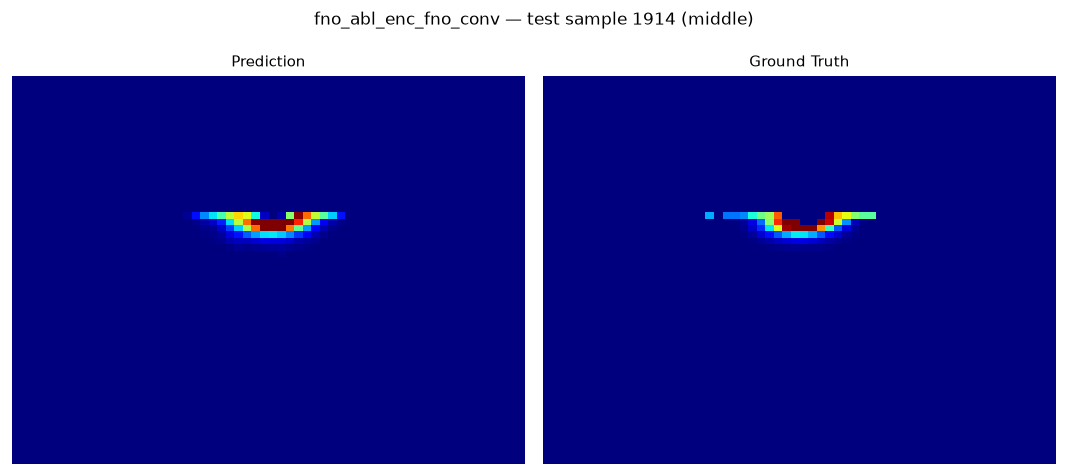

In [16]:
if preds_enc_fno_conv is not None:
    _mid = len(preds_enc_fno_conv) // 2
    _p = preds_enc_fno_conv[_mid]; _g = gts_enc_fno_conv[_mid]
    plot_comparison([('Prediction', _p[0]), ('Ground Truth', _g[0])],
                    f"{V['run_name']} — test sample {_mid} (middle)")


#### FNO-A PhysicsNeMo (calibration)


In [17]:
V = ENC_VARIANTS['fno_pre_pnemo']
plot_loss_curves(V, model_label='Encoder')


No wandb_run_id or wandb_run_name set for fno_abl_enc_fno_pre_pnemo


In [18]:
try:
    preds_enc_fno_pre_pnemo, gts_enc_fno_pre_pnemo = load_wandb_preds(V)
    print(f"Loaded {len(preds_enc_fno_pre_pnemo)} predictions from W&B artifact.")
    _loaded = True
except Exception as _e:
    print(f"Artifact not yet available: {_e}")
    preds_enc_fno_pre_pnemo = gts_enc_fno_pre_pnemo = None; _loaded = False


Artifact not yet available: artifact membership 'fno_abl_enc_fno_pre_pnemo_eval_predictions:latest' not found in 'ngng-/Flow3D_SuperResolution'


In [19]:
if preds_enc_fno_pre_pnemo is not None:
    _mid = len(preds_enc_fno_pre_pnemo) // 2
    _p = preds_enc_fno_pre_pnemo[_mid]; _g = gts_enc_fno_pre_pnemo[_mid]
    plot_comparison([('Prediction', _p[0]), ('Ground Truth', _g[0])],
                    f"{V['run_name']} — test sample {_mid} (middle)")


## 2. Diffusion + Encoder Results

DDIM-sampled DDPM conditioned on each frozen encoder (DDIM skip=50).  
Artifacts uploaded by `slurm/fno_ablation/03_eval_array.sh`.

#### RRDB CNN (baseline)


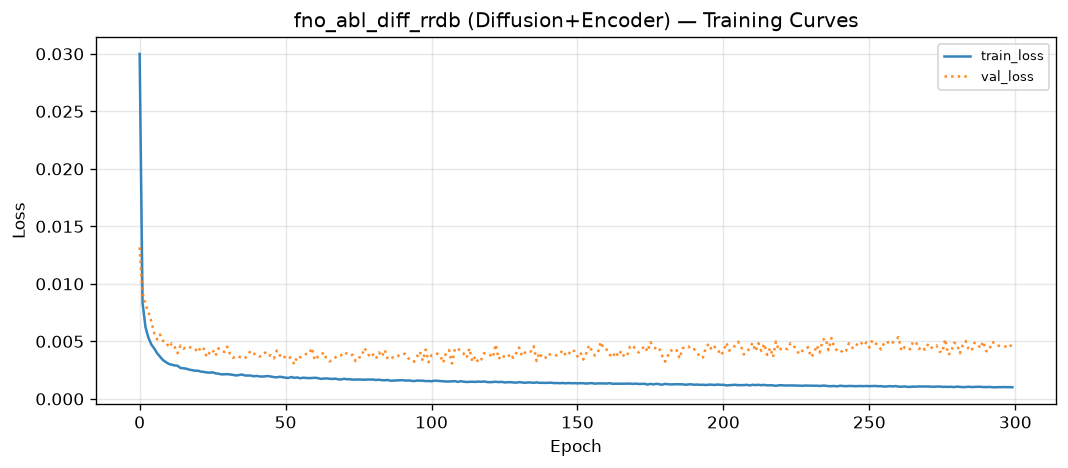

In [20]:
V = DIFF_VARIANTS['rrdb']
plot_loss_curves(V, model_label='Diffusion+Encoder')


In [21]:
try:
    preds_diff_rrdb, gts_diff_rrdb = load_wandb_preds(V)
    print(f"Loaded {len(preds_diff_rrdb)} predictions from W&B artifact.")
    _loaded = True
except Exception as _e:
    print(f"Artifact not yet available: {_e}")
    preds_diff_rrdb = gts_diff_rrdb = None; _loaded = False


wandb: Downloading large artifact 'fno_abl_diff_rrdb_eval_predictions:latest', 105.17MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:02.3 (45.5MB/s)


Loaded 3829 predictions from W&B artifact.


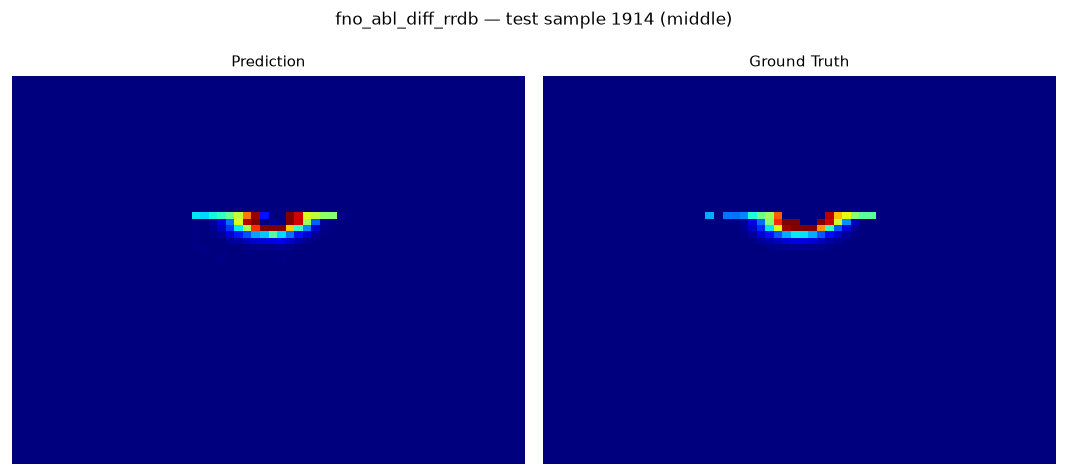

In [22]:
if preds_diff_rrdb is not None:
    _mid = len(preds_diff_rrdb) // 2
    _p = preds_diff_rrdb[_mid]; _g = gts_diff_rrdb[_mid]
    plot_comparison([('Prediction', _p[0]), ('Ground Truth', _g[0])],
                    f"{V['run_name']} — test sample {_mid} (middle)")


#### FNO-A (bicubic→HR, op@HR)


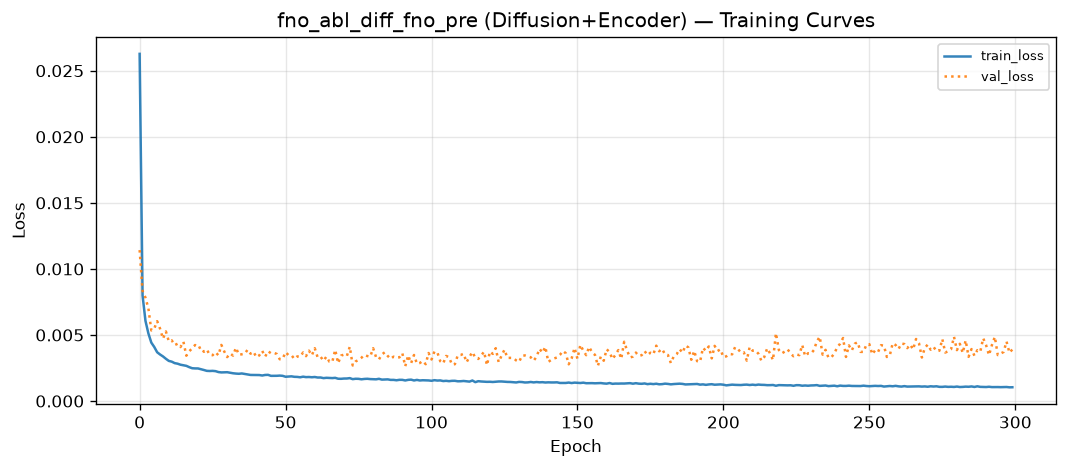

In [23]:
V = DIFF_VARIANTS['fno_pre']
plot_loss_curves(V, model_label='Diffusion+Encoder')


In [24]:
try:
    preds_diff_fno_pre, gts_diff_fno_pre = load_wandb_preds(V)
    print(f"Loaded {len(preds_diff_fno_pre)} predictions from W&B artifact.")
    _loaded = True
except Exception as _e:
    print(f"Artifact not yet available: {_e}")
    preds_diff_fno_pre = gts_diff_fno_pre = None; _loaded = False


wandb: Downloading large artifact 'fno_abl_diff_fno_pre_eval_predictions:latest', 105.17MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.4 (259.0MB/s)


Loaded 3829 predictions from W&B artifact.


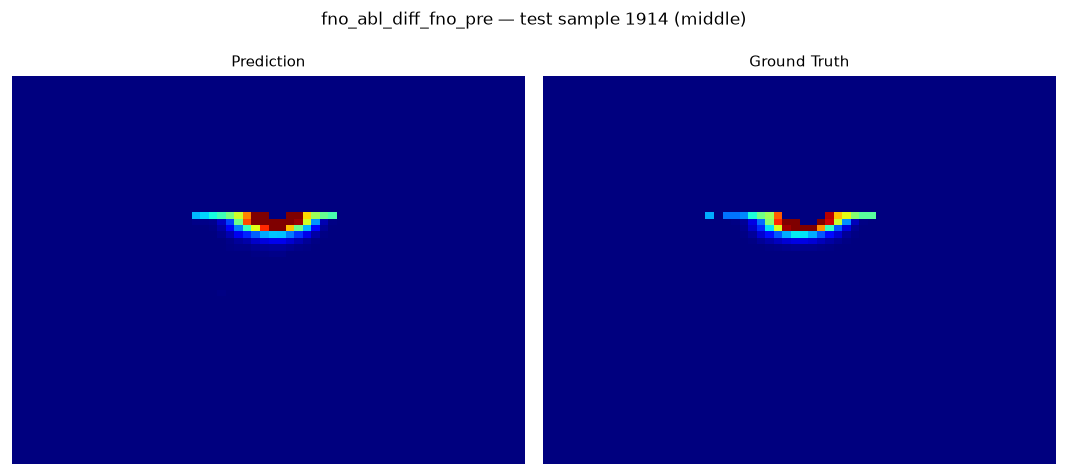

In [25]:
if preds_diff_fno_pre is not None:
    _mid = len(preds_diff_fno_pre) // 2
    _p = preds_diff_fno_pre[_mid]; _g = gts_diff_fno_pre[_mid]
    plot_comparison([('Prediction', _p[0]), ('Ground Truth', _g[0])],
                    f"{V['run_name']} — test sample {_mid} (middle)")


#### FNO-B (op@LR, spectral upsample)


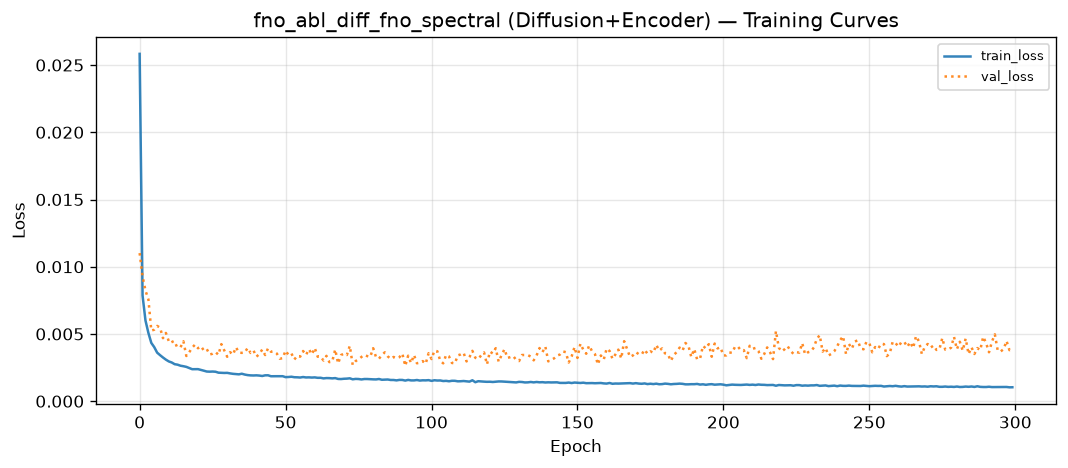

In [26]:
V = DIFF_VARIANTS['fno_spectral']
plot_loss_curves(V, model_label='Diffusion+Encoder')


In [27]:
try:
    preds_diff_fno_spectral, gts_diff_fno_spectral = load_wandb_preds(V)
    print(f"Loaded {len(preds_diff_fno_spectral)} predictions from W&B artifact.")
    _loaded = True
except Exception as _e:
    print(f"Artifact not yet available: {_e}")
    preds_diff_fno_spectral = gts_diff_fno_spectral = None; _loaded = False


wandb: Downloading large artifact 'fno_abl_diff_fno_spectral_eval_predictions:latest', 105.17MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:02.1 (49.8MB/s)


Loaded 3829 predictions from W&B artifact.


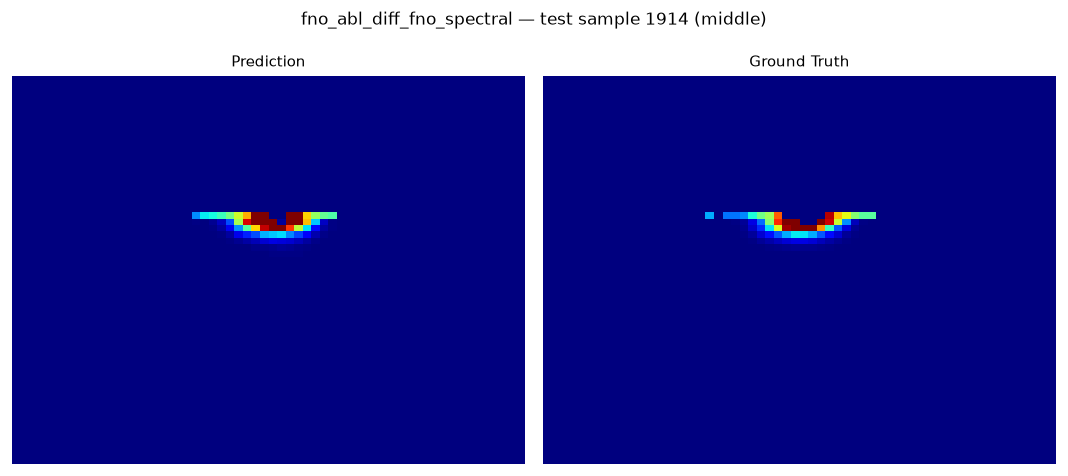

In [28]:
if preds_diff_fno_spectral is not None:
    _mid = len(preds_diff_fno_spectral) // 2
    _p = preds_diff_fno_spectral[_mid]; _g = gts_diff_fno_spectral[_mid]
    plot_comparison([('Prediction', _p[0]), ('Ground Truth', _g[0])],
                    f"{V['run_name']} — test sample {_mid} (middle)")


#### FNO-C (op@LR, conv upsample)


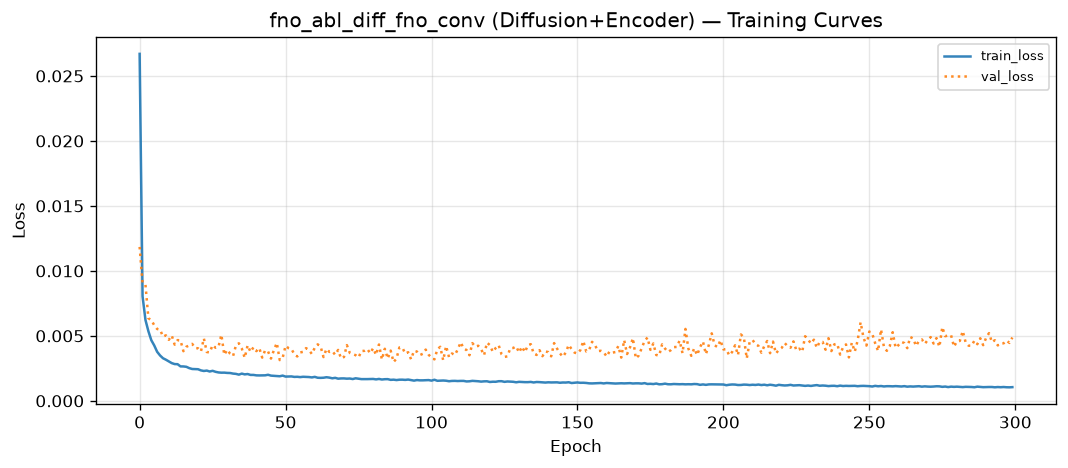

In [29]:
V = DIFF_VARIANTS['fno_conv']
plot_loss_curves(V, model_label='Diffusion+Encoder')


In [30]:
try:
    preds_diff_fno_conv, gts_diff_fno_conv = load_wandb_preds(V)
    print(f"Loaded {len(preds_diff_fno_conv)} predictions from W&B artifact.")
    _loaded = True
except Exception as _e:
    print(f"Artifact not yet available: {_e}")
    preds_diff_fno_conv = gts_diff_fno_conv = None; _loaded = False


wandb: Downloading large artifact 'fno_abl_diff_fno_conv_eval_predictions:latest', 105.17MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:02.6 (40.3MB/s)


Loaded 3829 predictions from W&B artifact.


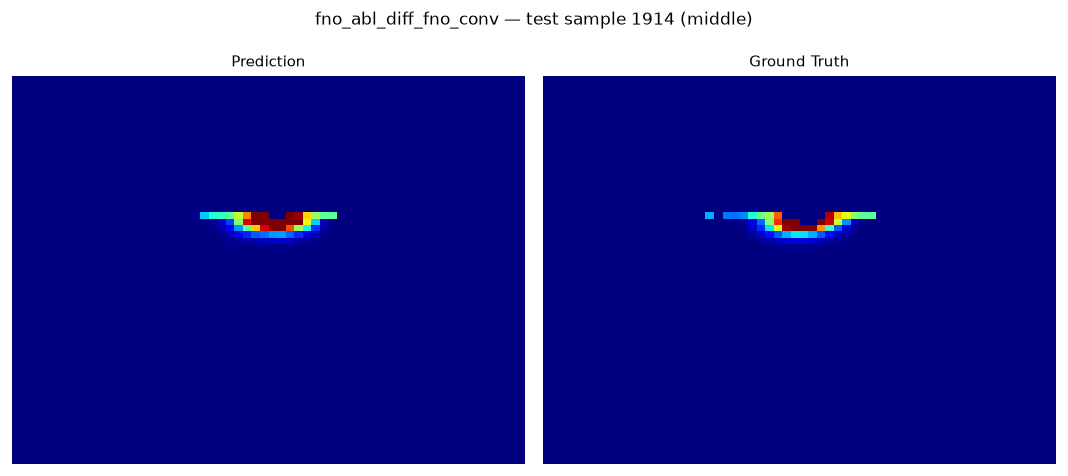

In [31]:
if preds_diff_fno_conv is not None:
    _mid = len(preds_diff_fno_conv) // 2
    _p = preds_diff_fno_conv[_mid]; _g = gts_diff_fno_conv[_mid]
    plot_comparison([('Prediction', _p[0]), ('Ground Truth', _g[0])],
                    f"{V['run_name']} — test sample {_mid} (middle)")


#### FNO-A PhysicsNeMo (calibration)


In [32]:
V = DIFF_VARIANTS['fno_pre_pnemo']
plot_loss_curves(V, model_label='Diffusion+Encoder')


No wandb_run_id or wandb_run_name set for fno_abl_diff_fno_pre_pnemo


In [33]:
try:
    preds_diff_fno_pre_pnemo, gts_diff_fno_pre_pnemo = load_wandb_preds(V)
    print(f"Loaded {len(preds_diff_fno_pre_pnemo)} predictions from W&B artifact.")
    _loaded = True
except Exception as _e:
    print(f"Artifact not yet available: {_e}")
    preds_diff_fno_pre_pnemo = gts_diff_fno_pre_pnemo = None; _loaded = False


Artifact not yet available: artifact membership 'fno_abl_diff_fno_pre_pnemo_eval_predictions:latest' not found in 'ngng-/Flow3D_SuperResolution'


In [34]:
if preds_diff_fno_pre_pnemo is not None:
    _mid = len(preds_diff_fno_pre_pnemo) // 2
    _p = preds_diff_fno_pre_pnemo[_mid]; _g = gts_diff_fno_pre_pnemo[_mid]
    plot_comparison([('Prediction', _p[0]), ('Ground Truth', _g[0])],
                    f"{V['run_name']} — test sample {_mid} (middle)")


## 3. Head-to-Head Comparison

Metrics table and bar chart: encoder-only vs diffusion+encoder for each arm.

In [35]:
# ── Metrics comparison table ──────────────────────────────────────────────────
rows = []
for arm in ARMS:
    ev = ENC_VARIANTS[arm]; dv = DIFF_VARIANTS[arm]
    ep = locals().get(f'preds_enc_{arm.replace("-","_")}')
    eg = locals().get(f'gts_enc_{arm.replace("-","_")}')
    dp = locals().get(f'preds_diff_{arm.replace("-","_")}')
    dg = locals().get(f'gts_diff_{arm.replace("-","_")}')
    row = {'Arm': ev['label']}
    if ep is not None: row.update({'Enc MAE': summarise_metrics(ev,ep,eg)['MAE_mean'],
                                   'Enc MP-MAE': summarise_metrics(ev,ep,eg)['MP_MAE_mean']})
    if dp is not None: row.update({'Diff MAE': summarise_metrics(dv,dp,dg)['MAE_mean'],
                                   'Diff MP-MAE': summarise_metrics(dv,dp,dg)['MP_MAE_mean']})
    rows.append(row)
df = pd.DataFrame(rows).set_index('Arm')
print(df.to_string(float_format='{:.4f}'.format))
display(df.style.format('{:.4f}').background_gradient(cmap='RdYlGn_r', axis=0))


                                 Enc MAE  Enc MP-MAE  Diff MAE  Diff MP-MAE
Arm                                                                        
RRDB CNN (baseline)              26.5852      0.4884   34.1057       0.6386
FNO-A (op@HR)                    32.1519      0.6829   36.2176       0.6909
FNO-B (spectral upsample)        33.2791      0.7055   36.6374       0.7090
FNO-C (conv upsample)            31.6489      0.6834   36.5436       0.7018
FNO-A PhysicsNeMo (calibration)      NaN         NaN       NaN          NaN


,Enc MAE,Enc MP-MAE,Diff MAE,Diff MP-MAE
Arm,,,,
RRDB CNN (baseline),26.5852,0.4884,34.1057,0.6386
FNO-A (op@HR),32.1519,0.6829,36.2176,0.6909
FNO-B (spectral upsample),33.2791,0.7055,36.6374,0.7090
FNO-C (conv upsample),31.6489,0.6834,36.5436,0.7018
FNO-A PhysicsNeMo (calibration),nan,nan,nan,nan


In [36]:
# ── Bar chart: Encoder MAE vs Diffusion MAE per arm ──────────────────────────
_arms_done = [a for a in ARMS if locals().get(f'preds_enc_{a.replace("-","_")}') is not None]
if _arms_done:
    labels  = [ENC_VARIANTS[a]['label'] for a in _arms_done]
    enc_mae = [summarise_metrics(ENC_VARIANTS[a],
                                 locals()[f'preds_enc_{a.replace("-","_")}'],
                                 locals()[f'gts_enc_{a.replace("-","_")}'])['MAE_mean']
               for a in _arms_done]
    diff_done = [a for a in _arms_done if locals().get(f'preds_diff_{a.replace("-","_")}') is not None]
    diff_mae  = [summarise_metrics(DIFF_VARIANTS[a],
                                   locals()[f'preds_diff_{a.replace("-","_")}'],
                                   locals()[f'gts_diff_{a.replace("-","_")}'])['MAE_mean']
                 for a in diff_done]

    x = np.arange(len(labels)); w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
    ax.bar(x - w/2, enc_mae, w, label='Encoder only', color='steelblue', alpha=0.85)
    if len(diff_done) == len(_arms_done):
        ax.bar(x + w/2, diff_mae, w, label='Diffusion + Encoder', color='tomato', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('MAE (physical units)'); ax.set_title('FNO vs RRDB — Encoder-only vs Diffusion MAE')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3); plt.tight_layout(); plt.show()
